<a href="https://colab.research.google.com/github/jhlopesalves/data-science-notebooks/blob/main/Python/machine_learning/housing_datasets/housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 1 - Framing the Problem, Metrics, and Honest Baselines

Machine learning begins not with algorithms, but with framing.  
Every project should start by articulating the **prediction task** in precise terms: what one row of data represents, what the target variable is, and how errors will be evaluated. This stage is often neglected in practice, but it establishes the ground rules for the entire modeling process.

### 1.1 Defining the Task

In supervised learning, we assume that measurable features $X$ contain information about a target variable $y$.  
When the target is continuous (for example, the sale price of a house), the task is called **regression**.

A well-framed problem statement should answer at least the following questions:

- **Unit of analysis.** What does each row represent? (e.g., *one property sold*).
- **Target definition.** Exactly what are we predicting, including units? (e.g., *sale price in US dollars at the time of sale*).
- **Availability.** Is the target observable at training time, and would it be available at prediction time?  
  Beware *data leakage*, where you accidentally use future information that would not be known at inference.

### 1.2 Measuring Error

A model's usefulness depends on how its errors align with stakeholder needs. Different error metrics encode different views of what "good performance" means.

- **Mean Absolute Error (MAE).**  
  Defined as  
  $$
  \text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|
  $$  
  Interpreted as "the average size of a typical miss." Robust to outliers and easy to explain.

- **Root Mean Squared Error (RMSE).**  
  Defined as  
  $$
  \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2}
  $$  
  Penalizes large errors more heavily. Appropriate when occasional large deviations are especially costly.

- **Coefficient of Determination (R²).**  
  Defined as  
  $$
  R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
  $$  
  Measures the proportion of variance explained relative to a baseline that always predicts the mean. Intuitive, but less reliable when the target distribution shifts.

> **Guideline:** Choose one *primary* metric that reflects the true cost of error, and track at least one *secondary* metric for robustness.

### 1.3 Baselines

Before deploying complex models, it is essential to compute **baselines**.  
A baseline is a deliberately simple predictor, often the mean or median of the target in the training set.

- Purpose: to establish a "floor" of expected performance.  
- Interpretation: if your sophisticated model performs no better than the median predictor, either there is no signal in the features or your modeling pipeline is flawed.

### 1.4 Guardrails for Honest Evaluation

To maintain rigor:

1. **Split early.** Divide data into training and test sets before performing any preprocessing or modeling.  
2. **Use pipelines.** Encapsulate preprocessing and modeling in a single object, ensuring consistent transformations at training and inference.  
3. **Ensure reproducibility.** Fix random seeds, record software versions, and, when possible, snapshot the dataset.

> **Mantra:** *Measure what you do. Do not rely on intuition alone; enforce evidence through metrics and baselines.*

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

data = fetch_california_housing(as_frame=True)
X = data.frame.drop(columns=["MedHouseVal"])
y = data.frame["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

baseline = DummyRegressor(strategy="median").fit(X_train, y_train)
pred = baseline.predict(X_test)

rmse = mean_squared_error(y_test, pred) ** 0.5
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"RMSE: {round(rmse, 3)}, MAE: {round(mae, 3)}, R2: {round(r2, 3)}")

RMSE: 1.203, MAE: 0.897, R2: -0.076


## Pre-Lesson 2 - Dataset Mimicry: Crafting Synthetic Features, Noise, and Missingness

Data scientists often need “toy universes”: simplified or mimicked datasets where principles can be tested
without leaking insights from the real problem. Constructing such datasets develops a deeper intuition for
what distributions look like and how different types of corruption affect modeling.

### Why mimic data?

1. **Teaching and communication.** A simple, controlled dataset illustrates principles better than a messy real one.  
2. **Pipeline testing.** Synthetic columns let you check if imputation, encoding, or scaling behave as intended.  
3. **Resilience training.** By injecting missing values or noise, you prepare your models for the messiness of real-world data.  
4. **Conceptual clarity.** Building data forces you to think about distributions, cardinalities, and interactions explicitly.

### 2.0 Tools for mimicry

We rely mainly on:
- `numpy.random`: generates numbers from common distributions (uniform, normal, binomial).  
- `pandas`: integrates random values into tabular structures.  
- Controlled corruption: replacing values with `np.nan` or remapping categories.

### 2.1 Generating synthetic numeric features

- Uniform distribution: flat spread across an interval.  
- Normal distribution: bell-shaped with mean and standard deviation.  
- Skewed distributions: exponential, lognormal.  


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
# Set sample size for synthetic dataset generation
n = 1000

# Initialize random number generator with seed for reproducibility in simulations
rng = np.random.default_rng(42)

# Create a pandas DataFrame to mimic real data with synthetic features
mimic = pd.DataFrame(
    data={
        # Generate discrete uniform distribution for age (integer values between 18 and 79)
        "age": rng.integers(low=18, high=80, size=n),  # discrete uniform
        # Generate normal distribution for income (mean 50k, std 15k, continuous values)
        "income": rng.normal(loc=50_000, scale=15_000, size=n),  # normal
        # Generate lognormal distribution for house size (skewed positive, mean log 7.5, sigma 0.5)
        "house_size": rng.lognormal(mean=7.5, sigma=0.5, size=n),  # skewed
    }
)

mimic.head()

,age,income,house_size
0,23,71498.217599,2396.240996
1,65,51372.802673,1914.654023
2,58,58711.656430,2132.332584
3,45,49148.252084,2667.254020
4,44,47443.886283,1206.232133


### 2.2 Crafting categorical features

- Categories can be drawn from lists with given probabilities, allowing you to simulate low- and high-cardinality scenarios.

In [ ]:
# Define a list of city names for categorical feature simulation
cities = ["Castle Rock", "Maine", "Belo Horizonte", "London"]

# Sample from the cities list with specified probabilities to create a skewed categorical distribution
mimic["city"] = rng.choice(cities, size=n, p=[0.4, 0.3, 0.2, 0.1])

# Generate a list of neighborhood names to simulate high-cardinality categorical feature
neighbourhoods = [f"NBH_{i}" for i in np.arange(1, 51)]  # High-cardinality example

# Randomly assign neighborhoods to each row, demonstrating uniform sampling for high-cardinality
mimic["neighbourhoods"] = rng.choice(neighbourhoods, size=n)
mimic.head()

,age,income,house_size,city,neighbourhoods
0,23,71498.217599,2396.240996,Maine,NBH_15
1,65,51372.802673,1914.654023,Belo Horizonte,NBH_40
2,58,58711.656430,2132.332584,Castle Rock,NBH_31
3,45,49148.252084,2667.254020,Castle Rock,NBH_12
4,44,47443.886283,1206.232133,Maine,NBH_36


### 2.3 Injecting missingness

- You can deliberately set some values to NaN, either uniformly at random or according to a condition (to simulate MNAR).

In [ ]:
# Generate a boolean mask for MCAR missingness: randomly select 10% of rows for 'income' column
mask = rng.random(n) < 0.1
# Set 'income' to NaN where mask is True, simulating missing completely at random (MCAR)
mimic.loc[mask, "income"] = np.nan

# Create a conditional mask for MNAR missingness: higher probability for 'house_size' if age > 60
mask2 = (mimic["age"] > 60) & (rng.random(n) < 0.2)
# Set 'house_size' to NaN based on the conditional mask, simulating missing not at random (MNAR)
mimic.loc[mask2, "house_size"] = np.nan

mimic.isna().sum()

age                0
income            88
house_size        71
city               0
neighbourhoods     0
dtype: int64

In [ ]:
display(mimic)

,age,income,house_size,city,neighbourhoods
0,23,71498.217599,2396.240996,Maine,NBH_15
1,65,51372.802673,1914.654023,Belo Horizonte,NBH_40
2,58,58711.656430,2132.332584,Castle Rock,NBH_31
3,45,49148.252084,2667.254020,Castle Rock,NBH_12
4,44,47443.886283,1206.232133,Maine,NBH_36
...,...,...,...,...,...
995,56,NaN,654.708577,Castle Rock,NBH_33
996,50,28142.931306,2009.933452,Castle Rock,NBH_11
997,40,NaN,2646.715248,Maine,NBH_28
998,77,75587.790208,NaN,Castle Rock,NBH_41




### **Exercise:** Build your own synthetic dataset with at least:


> 1. One continuous skewed numeric variable.
> 2. One ordinal categorical variable (e.g., quality rating from 1–5).
> 3. One nominal categorical variable with high cardinality (e.g., 100 IDs).
> 4. Inject at least 10% missingness into one variable, and conditionally add more missingness based on another.



> Write a short description of what each column is supposed to represent in the “world” of your dataset.

Numerical Values

In [ ]:
n = 1000

rng = np.random.default_rng(42)

# Numerical values
mimic_housing = pd.DataFrame(
    data={
        "age": rng.integers(low=5, high=95, size=n),
        "house_size": rng.lognormal(mean=4.5, sigma=0.5, size=n),
        "price": rng.normal(loc=150_000, scale=50_000, size=n),
        "avg_rooms": rng.uniform(low=1.5, high=10.5, size=n),
    }
)
mimic_housing.head()

,age,house_size,price,avg_rooms
0,13,184.307812,178165.653676,6.770434
1,74,94.232025,155729.221851,8.533193
2,63,120.348121,166497.176933,4.895537
3,44,87.497341,188880.476514,1.611575
4,43,82.664993,109525.684055,6.087612


Categorical Values

In [ ]:
cities = ["Castle Rock", "Maine", "BH", "Camboriu", "London"]
mimic_housing["city"] = rng.choice(cities, size=n, p=[0.2, 0.2, 0.15, 0.05, 0.4])

neighbourhoods = [
    "Kobrasol",
    "Barreiros",
    "Tupi",
    "Jatobá",
    "Centro",
    "Floramar",
    "Guarani",
    "Santa Amélia",
]
mimic_housing["neighbourhood"] = rng.choice(neighbourhoods, size=n)

mimic_housing

,age,house_size,price,avg_rooms,city,neighbourhood
0,13,184.307812,178165.653676,6.770434,London,Kobrasol
1,74,94.232025,155729.221851,8.533193,Maine,Kobrasol
2,63,120.348121,166497.176933,4.895537,Camboriu,Kobrasol
3,44,87.497341,188880.476514,1.611575,Castle Rock,Floramar
4,43,82.664993,109525.684055,6.087612,Maine,Jatobá
...,...,...,...,...,...,...
995,61,256.723435,48419.021567,1.938502,London,Kobrasol
996,52,43.442188,160585.689209,1.648421,Maine,Guarani
997,37,74.044125,188107.462098,5.761279,London,Centro
998,91,211.225512,135996.568656,2.979409,BH,Tupi


Missingness

In [ ]:
# 10% missing completely at random
mask = rng.random(n) < 0.1
mimic_housing.loc[mask, "avg_rooms"] = np.nan

mask2 = (mimic_housing["age"] > 90) & (rng.random(n) < 0.2)
mimic_housing.loc[mask2, "house_size"] = np.nan

mimic_housing

,age,house_size,price,avg_rooms,city,neighbourhood
0,13,184.307812,178165.653676,6.770434,London,Kobrasol
1,74,94.232025,155729.221851,8.533193,Maine,Kobrasol
2,63,120.348121,166497.176933,4.895537,Camboriu,Kobrasol
3,44,87.497341,188880.476514,1.611575,Castle Rock,Floramar
4,43,82.664993,109525.684055,6.087612,Maine,Jatobá
...,...,...,...,...,...,...
995,61,256.723435,48419.021567,1.938502,London,Kobrasol
996,52,43.442188,160585.689209,1.648421,Maine,Guarani
997,37,74.044125,188107.462098,5.761279,London,Centro
998,91,NaN,135996.568656,NaN,BH,Tupi


## Pre-Lesson 2B — Strengthening a Synthetic Tabular Dataset

**Objective.** Extend a basic mimicry dataset by (i) introducing an ordinal categorical feature,
(ii) adding a high-cardinality nominal feature, (iii) generating a target that depends on features,
and (iv) injecting missingness with both MCAR and conditional patterns.

**Design notes.**
- **Ordinal** (`quality` 1–5) should correlate with price monotonically.
- **High-card nominal** (`street_id`) trains our encoders to behave under many rare levels.
- **Target generation**: linear-on-transformed features with city/neighbourhood random effects and heteroskedastic noise.
- **Sanity constraints**: nonnegative prices; heavy tails controlled.


In [ ]:
q_probs = [0.05, 0.20, 0.40, 0.25, 0.10]  # Skew toward mid quality
mimic_housing["quality"] = rng.choice([1, 2, 3, 4, 5], size=n, p=q_probs).astype(
    np.int16
)

# High-card nominal: 250 synthetic streets
streets = [f"ST_{i:03d}" for i in range(250)]
mimic_housing["street_id"] = rng.choice(streets, size=n)

mimic_housing

,age,house_size,price,avg_rooms,city,neighbourhood,quality,street_id
0,13,184.307812,178165.653676,6.770434,London,Kobrasol,3,ST_175
1,74,94.232025,155729.221851,8.533193,Maine,Kobrasol,2,ST_216
2,63,120.348121,166497.176933,4.895537,Camboriu,Kobrasol,4,ST_194
3,44,87.497341,188880.476514,1.611575,Castle Rock,Floramar,4,ST_107
4,43,82.664993,109525.684055,6.087612,Maine,Jatobá,5,ST_011
...,...,...,...,...,...,...,...,...
995,61,256.723435,48419.021567,1.938502,London,Kobrasol,3,ST_049
996,52,43.442188,160585.689209,1.648421,Maine,Guarani,3,ST_243
997,37,74.044125,188107.462098,5.761279,London,Centro,3,ST_233
998,91,NaN,135996.568656,NaN,BH,Tupi,3,ST_004


In [ ]:
# city base effects (multiplicative), neighbourhood random noise, plus size/rooms/quality contributions
city_effect = {
    "London": 2.5,
    "Maine": 1,
    "Castle Rock": 1.15,
    "BH": 1.75,
    "Camboriu": 1.15,
}
nbh_effect = {
    nbh: rng.normal(1.0, 0.05) for nbh in mimic_housing["neighbourhood"].unique()
}

# Helper to get effects
ce = mimic_housing["city"].map(city_effect)
ne = mimic_housing["neighbourhood"].map(nbh_effect)

# construct latent log-price; guard against NaNs in house_size/avg_rooms via safe fills for generation
hs = mimic_housing["house_size"].fillna(mimic_housing["house_size"].median())
ar = mimic_housing["avg_rooms"].fillna(mimic_housing["avg_rooms"].median())

# diminishing returns with log(house_size), additive quality, modest rooms effect
log_price_latent = (
    11.0
    + 0.45 * np.log(hs + 1)
    + 0.06 * ar
    + 0.12
    + mimic_housing["quality"]
    + np.log(ce)
    + np.log(ne)
)

eps = rng.normal(
    loc=0.0, scale=0.12 * np.abs(np.log(hs + 1) - np.log(hs + 1).median()), size=n
)
price_generated = np.exp(log_price_latent + eps)

# re-scale to a realistic unit: bring median near 180k
scale = 180_000 / np.median(price_generated)
mimic_housing["price"] = np.maximum(10_000, price_generated * scale)

Inject missingness with both MCAR and conditional patterns

In [ ]:
# 10% MCAR in avg_rooms (kept from your version)
mask_mcar = rng.random(n) < 0.10
mimic_housing.loc[mask_mcar, "avg_rooms"] = np.nan

# additional conditional missingness: very old buildings more likely to miss house_size
mask_cond = (mimic_housing["age"] > 90) & (rng.random(n) < 0.20)
mimic_housing.loc[mask_cond, "house_size"] = np.nan

# optional: MNAR-ish missingness in quality for certain cities
mask_city = (mimic_housing["city"].isin(["London", "BH"])) & (rng.random(n) < 0.05)
mimic_housing.loc[mask_city, "quality"] = np.nan

Quick audit: sanity check

In [ ]:
audit = pd.DataFrame(
    {
        "dtype": mimic_housing.dtypes.astype(str),
        "n_unique": mimic_housing.nunique(),
        "n_missing": mimic_housing.isna().sum(),
        "pct_missing": (100 * mimic_housing.isna().mean()).round(1),
    }
).sort_values(["pct_missing", "n_unique"], ascending=[False, True])
audit

,dtype,n_unique,n_missing,pct_missing
avg_rooms,float64,790,210,21.0
quality,float64,5,19,1.9
house_size,float64,985,15,1.5
city,object,5,0,0.0
neighbourhood,object,8,0,0.0
age,int64,90,0,0.0
street_id,object,245,0,0.0
price,float64,999,0,0.0


## Lesson 2 - Data Audit: Profiling, Missingness, and Cardinality

Before modeling, we must **read** the dataset. This stage is often called **data audit** or **profiling**.  
The purpose is not to “fix” anything yet, but to develop a clear map of what’s present, what’s missing, and what looks unusual.  
Think of it as reconnaissance: you are surveying the terrain before you build.

### 2.1 Types of Variables
Every column should be classified properly:
- **Numeric (continuous/discrete).** Examples: square footage, year built, number of rooms.
- **Categorical (nominal/ordinal).** Examples: neighborhood (nominal), quality rating (ordinal).
- **Identifiers.** Columns like IDs, parcel numbers, or addresses are not predictive and should usually be excluded.

Incorrect types are common: integers used as category labels, text fields where ordinals should be, or floats that are really IDs.

### 2.2 Missingness
Missing values are not all the same. Statisticians describe three types:
- **MCAR (Missing Completely at Random).** No pattern; any value could be missing.
- **MAR (Missing at Random).** Missingness depends on other observed variables.
- **MNAR (Missing Not at Random).** Missingness depends on the value itself (e.g., luxury homes less likely to disclose renovations).

Understanding which applies guides how you impute. At the audit stage, you’re simply measuring:
- Total missing values per column.
- Percentage of missingness.
- Whether missingness clusters in certain variables.

### 2.3 Cardinality of Categorical Features
Categorical variables vary in complexity:
- **Low cardinality**: few unique values (e.g., “Yes/No”).
- **Moderate cardinality**: manageable groups (e.g., 10–20 neighborhoods).
- **High cardinality**: many unique values (e.g., thousands of unique zip codes).

High cardinality can be powerful but introduces risks:
- Overfitting (rare levels appear only once).
- Leakage (if a category encodes target information too directly).
- Inefficient encoding (too many one-hot columns).

### 2.4 Low-Variance Traps
Columns that are nearly constant or have extremely skewed distributions provide little signal but can bloat the feature space.  
Part of your audit is flagging them for possible removal or re-encoding.


### 2.5 Audit as Narrative
At the end of the audit, you should be able to write a one-page summary answering:
- What types of variables are present?
- Which columns are most missing, and what risks does this pose?
- Which features are high cardinality and need careful encoding?
- Which features are nearly constant and may be dropped?

Remember: at this stage you are **observing, not altering.**


In [ ]:
from sklearn.datasets import fetch_california_housing

# load data
data = fetch_california_housing(as_frame=True)
california = data.frame.rename(columns={"MedHouseVal": "target"})

# Create some categorical variables for illustration
california["lat_band"] = pd.cut(
    california["Latitude"],
    bins=[-np.inf, 33, 36, 39, np.inf],
    labels=["South", "Central", "North", "FarNorth"],
)

california["is_coastal"] = (california["Longitude"] < -122).map(
    {True: "Coastal", False: "Inland"}
)

# Inject some missingness
rng = np.random.default_rng(42)
mask = rng.random(len(california)) < 0.05
california.loc[mask, "AveRooms"] = np.nan

# Audit summary
audit = pd.DataFrame(
    {
        "dtype": california.dtypes.astype(str),
        "n_unique": california.nunique(),
        "n_missing": california.isna().sum(),
        "pct_missing": (100 * california.isna().mean()).round(1),
    }
).sort_values(["pct_missing", "n_unique"], ascending=[False, True])

display(audit)

,dtype,n_unique,n_missing,pct_missing
AveRooms,float64,18466,1028,5.0
is_coastal,object,2,0,0.0
lat_band,category,4,0,0.0
HouseAge,float64,52,0,0.0
Longitude,float64,844,0,0.0
Latitude,float64,862,0,0.0
target,float64,3842,0,0.0
Population,float64,3888,0,0.0
MedInc,float64,12928,0,0.0
AveBedrms,float64,14233,0,0.0


## Pre-Lesson 2B - Structured Target Generation with Log-Linear Models

So far, we have generated *features* (size, rooms, quality, city).  
But a dataset is not complete until the **target variable** (e.g., price) is defined in a principled way.

The goal here is to design a target that:
1. **Depends meaningfully on features** (signal).  
2. **Has realistic distributional properties** (positive, skewed).  
3. **Includes randomness** (noise) so models cannot be perfect.  

This is done using a **log-linear latent model**:
$$
\log(\text{price}) = \text{intercept} + \alpha \cdot f(\text{size}) + \beta \cdot \text{rooms} + \gamma \cdot \text{quality} + \delta_{\text{city}} + \epsilon
$$

- On the **log scale**, contributions from features combine additively (straightforward math).  
- We then **exponentiate** to return to the original positive scale of dollars.  
- This yields a **lognormal-like price distribution**, which matches real estate better than a plain normal.

### Step 1. The Intercept (Baseline Level)

Every model starts with a baseline.  
On the log scale, the intercept determines the **typical log-price** before adding feature effects.

```python
intercept = 11.0  # log-scale baseline
````

This corresponds to a baseline price of:

```python
np.exp(intercept) ≈ 60,000
```

Think of it as: *if a house had “average everything,” it’d cost around $60k before adjustments.*

### Step 2. Feature Contributions

Each feature adds or subtracts from the log-price.

* **House size**: Bigger houses cost more, but not linearly. Doubling size does not double price.
  Solution: use `np.log(size)` → diminishing returns.

  ```python
  + 0.45 * np.log(size)
  ```
* **Rooms**: Each additional room contributes modestly.

  ```python
  + 0.06 * rooms
  ```
* **Quality**: Ordinal 1–5, each step up adds value.

  ```python
  + 0.12 * quality
  ```
* **City / neighborhood effects**: Encode multiplicative differences.
  For example, London ×1.3 vs Maine ×0.95. On the log-scale, this becomes `+ np.log(city_effect)`.

So the formula starts to look like:

```python
log_price = intercept + 0.45*np.log(size) + 0.06*rooms + 0.12*quality + np.log(city_effect) + np.log(nbh_effect)
```

### Step 3. Noise (Uncertainty)

Real markets are noisy.
Two identical houses rarely sell for the same price.
We add a **Normal(0, σ)** random variable to the log-price:

```python
noise = rng.normal(loc=0.0, scale=0.12, size=n)
```

* `loc=0.0` → centered around no bias.
* `scale=0.12` → controls spread (like 12% variability).
* Sometimes we let bigger houses have bigger variance (heteroskedasticity). That’s why you saw:

  ```python
  scale = 0.12 + 0.02*(np.log(size) - np.mean(np.log(size)))
  ```

### Step 4. Back to Dollars

Now we exponentiate:

```python
price = np.exp(log_price + noise)
```

This guarantees:

* Prices are **positive**.
* Distribution is **right-skewed**.
* Relationships are **multiplicative** (percent changes stack).

### Step 5. Rescaling for Realism

You can rescale prices so the median matches a realistic market (e.g., 180k):

```python
scale_factor = 180_000 / np.median(price)
price_rescaled = price * scale_factor
```

Optional: enforce a floor so no house is cheaper than, say, 10k:

```python
price_rescaled = np.maximum(10_000, price_rescaled)
```

### Putting it Together

```python
hs = df["size"].fillna(df["size"].median())        # guard against NaN
ar = df["rooms"].fillna(df["rooms"].median())      # guard against NaN
quality = df["quality"].fillna(3)                  # mid-quality if missing

city_effect = {"London":1.3,"Maine":0.95,"Castle Rock":1.05,"BH":1.1,"Camboriu":1.15}
ce = df["city"].map(city_effect)

log_price = (
    11.0
    + 0.45*np.log(hs+1)
    + 0.06*ar
    + 0.12*quality
    + np.log(ce)
)

noise = rng.normal(0, 0.12, size=len(df))
price = np.exp(log_price + noise)

scale = 180_000 / np.median(price)
df["price"] = np.maximum(10_000, price*scale)
```

### Key Intuitions

1. **Log-transform**: turns multiplicative effects (10% increase here, 20% there) into additive contributions.
2. **Exponentiate**: ensures the final target is positive and skewed.
3. **Coefficients**: adjust strength of each feature’s influence.
4. **Noise**: prevents a “perfect” world; it creates the uncertainty that models must grapple with.

> You are not memorizing a recipe. You are learning a design pattern: *latent log-linear model → exponentiation → positive skewed target*.

## Coding Challenge - Design a Synthetic Housing World (End-to-End)

**Goal.** Build a fully synthetic tabular dataset that mimics a realistic housing market.  
Your dataset must include mixed data types, coherent relationships, structured noise, and controlled missingness.  
The target variable (price) must be positive, right-skewed, and meaningfully driven by features.

You will:
1) Specify the *world* (distributions, categories, and effects).  
2) Generate features with explicit rationale.  
3) Construct a **log-linear latent model** for price, add noise (possibly heteroskedastic), then exponentiate.  
4) Inject **MCAR** and **conditional** missingness.  
5) Produce an **audit report** and sanity plots.  
6) Write a brief “model card” for your synthetic data.

You will not:
- Use real housing datasets.
- Hardcode arbitrary constants without rationale (every parameter deserves a sentence).
- Skip the audit and checks.


### 1. World Specification (Design First, Then Code)

Describe (in prose) the world you are simulating:

**Geography.**  
- Define 4–6 cities with multiplicative price effects (e.g., City A ≈ +25%, City B ≈ −10%).  
- Each city contains 6–12 neighborhoods. Neighborhoods contribute smaller random effects around 1.0.

**Structure & Features.**  
- `size` (continuous, strictly positive, right-skewed).  
- `rooms` (integer, small range 1–10).  
- `quality` (ordinal 1–5, skewed toward the middle).  
- `age` (integer 1–120; consider realistic bounds).  
- `renovated` (binary; renovation discounts age effect partly).  
- One **high-cardinality** nominal feature (e.g., `street_id` with ≥250 unique labels).  
- One **derived ratio** (e.g., `rooms_per_100sqm`), to practice feature engineering later.

**Temporal (optional but recommended).**  
- `sale_year` drawn from a small window (e.g., 2017–2022) with a gentle market trend (e.g., +3% per year compounding).  
- Seasonality (optional): mild multiplicative effect by quarter.

Document all of the above in 10–15 sentences before coding. The story matters.



In [ ]:
rng = np.random.default_rng(42)

In [ ]:
# Define a list of cities to simulate diverse housing markets with varying price levels.
# Each city has a multiplicative effect on price (e.g., London at 2x baseline, Tel Aviv at 4x) to reflect real-world economic differences.
cities = ["London", "Paris", "Jerusalem", "Tel Aviv", "New York", "Oslo"]
# Probabilities for sampling cities, skewed towards London and New York to mimic common data distributions.
city_probs = [0.3, 0.1, 0.2, 0.1, 0.2, 0.1]
# Dictionary mapping cities to their price multipliers; multiplicative effects allow additive contributions on log scale.
cities_effect = {
    "London": 1.25,
    "Paris": 1.15,
    "Jerusalem": 1.35,
    "Tel Aviv": 1.40,
    "New York": 1.30,
    "Oslo": 1.10,
}


# Initialize an empty dictionary to store neighborhoods per city, enabling hierarchical random effects.
nbh = {}
# Loop over each city to generate neighborhoods dynamically; this simulates varying urban structures.
for city in cities:
    # Sample number of neighborhoods per city using RNG.integers to guarantee a positive integer count.
    # Choose between 6 and 12 neighborhoods per city (6..12), avoiding occasional negative or zero counts.
    k = int(rng.integers(6, 13))
    # Create neighborhood names using string formatting; f-strings provide concise interpolation.
    names = [f"{city[:2].upper()}_NBH_{i:02d}" for i in range(k)]

    nbh_effect = np.clip(rng.normal(1.0, 0.05, size=k), 0.85, 1.15)
    # Map names to effects in a dict; zip pairs iterables element-wise for dictionary creation.
    nbh[city] = dict(zip(names, nbh_effect))

# Generate a list of 300 unique street IDs; high cardinality (300) tests encoding robustness in models.
streets = [
    f"ST_{i:04d}" for i in range(300)
]  # Zero-padded formatting ensures consistent string length.

In [ ]:
# Define the range of sale years from 2007 to 2024 (inclusive start, exclusive end), creating an array for temporal sampling.
years = np.arange(2007, 2025)

# Create a linear array from 1 to 14 (matching the length of years), then normalize to probabilities summing to 1.
# This simulates increasing likelihood of sales in later years, mimicking real estate market trends.
year_weights = np.arange(1, len(years) + 1)
year_probs_local = year_weights / year_weights.sum()

# Set annual growth rate to 5% per year; this multiplicative factor will compound over time in price calculations.
annual_growth = 1.05

In [ ]:
# Initialize a pandas DataFrame with n rows (n=1000 from earlier cell), using index as row identifiers.
challenge = pd.DataFrame(index=range(n))

# Sample 'city' column from the list of cities with specified probabilities, ensuring skewed distribution (e.g., London more frequent).
challenge["city"] = rng.choice(cities, size=n, p=city_probs)

# For each city, randomly select a neighbourhood from its specific list in nbh dict, creating hierarchical categorical data.
challenge["neighbourhood"] = [
    rng.choice(list(nbh[c].keys())) for c in challenge["city"]
]

# Sample 'street_id' uniformly from the list of 300 unique street IDs, introducing high-cardinality nominal feature.
# High cardinality tests model robustness to many rare categories, common in real datasets like addresses.
challenge["street_id"] = rng.choice(streets, size=n)

# Sample 'sale_year' from the years array with increasing probabilities, simulating rising sales over time.
# This temporal feature allows modeling market trends, with later years more likely for realism.
challenge["sale_year"] = rng.choice(years, size=n, p=year_probs_local)

# Generate 'size' using lognormal distribution (mean=5, sigma=0.6), producing right-skewed positive values for house sizes.
# Lognormal ensures realistic skewness (most houses small, few very large), avoiding negative values.
challenge["size"] = rng.lognormal(mean=5, sigma=0.6, size=n)

# Sample 'rooms' as discrete integers from 1 to 10 (inclusive), representing number of rooms.
challenge["rooms"] = rng.integers(1, 11, size=n)

# Sample 'quality' as ordinal values from 1 to 5, representing housing quality levels (1=lowest, 5=highest).
# Probabilities are skewed toward mid-quality (3) to mimic real-world distributions where average quality is common.
challenge["quality"] = rng.choice(
    [1, 2, 3, 4, 5], size=n, p=[0.08, 0.22, 0.40, 0.18, 0.12]
)
quality_levels = {
    0: "very poor",
    1: "poor",
    2: "fair",
    3: "good",
    4: "very good",
    5: "excellent",
}


# rng.integers(low=1, high=121, size=n) produces integers >=1 and <121, i.e., 1 to 120.
# Uniform distribution ensures equal probability for each age, simulating no prior bias in age distribution.
challenge["age"] = rng.integers(1, 121, size=n)


# Sample 'renovated' as binary (0 or 1), with 70% not renovated (0) and 30% renovated (1).
challenge["renovated"] = rng.choice([0, 1], size=n, p=[0.7, 0.3])

# Compute derived feature 'rooms_per_100mts': rooms divided by size scaled to 100 units, with epsilon to avoid division by zero.
challenge["rooms_per_100mts"] = challenge["rooms"] / (challenge["size"] / 100.0 + 1e-6)

In [ ]:
# Map city multiplicative factors (e.g., London:2.0) onto each row.
# cities_effect is a dict of multiplicative price multipliers; .map aligns dict values by city name.
ce = challenge["city"].map(cities_effect)

# Map city multiplicative factors (e.g., London:2.0) onto each row.
# cities_effect is a dict of multiplicative price multipliers; .map aligns dict values by city name.
ce = challenge["city"].map(cities_effect)

# Map neighbourhood effects: nbh is a nested dict (city -> neighbourhood -> effect).
# Use list comprehension to lookup each row's effect; zip pairs city and neighbourhood columns.
# pd.Series constructor creates a Series with matching index and name for easy DataFrame assignment.
ne = pd.Series(
    [
        nbh[city][nb_name]
        for city, nb_name in zip(challenge["city"], challenge["neighbourhood"])
    ],
    index=challenge.index,
    name="nbh_effect",
)

# Compute years since the earliest sale_year in the sample; small integer dtype saves memory.
years_since = (challenge["sale_year"] - challenge["sale_year"].min()).astype(np.int16)

# Convert an annual multiplicative growth (e.g., 1.05 => +5% per year) into an additive log-scale term.
# On the log-price scale, repeated multiplicative growth compounds additively via log(annual_growth) * years_since.
time_effect = np.log(annual_growth) * years_since

# Compute years since the earliest sale_year in the sample; small integer dtype saves memory.
years_since = (challenge["sale_year"] - challenge["sale_year"].min()).astype(np.int16)

# Convert an annual multiplicative growth (e.g., 1.05 => +5% per year) into an additive log-scale term.
# On the log-price scale, repeated multiplicative growth compounds additively via log(annual_growth) * years_since.
time_effect = np.log(annual_growth) * years_since

### 2. Target Generation (Log-Linear Latent Model)

Define the price model on the log scale:

$$
\log(\text{price}) = \beta_0 + \alpha \cdot \log(\text{size}) + \beta \cdot \text{rooms} + \gamma \cdot \text{quality} + \phi \cdot \text{renovated} \\
\quad + \lambda \cdot f(\text{age}, \text{renovated}) + \text{city\_effect} + \text{nbh\_effect} + \text{time\_trend} + \epsilon
$$

**Design requirements.**
- Choose coefficients and explain them (one line each).  
- Use $\log(\text{size})$ to encode diminishing returns.  
- Model **age** so that renovation reduces its penalty (e.g., older homes hurt less if $\text{renovated} = 1$).  
- Add a **time trend** if you include $\text{sale\_year}$ (e.g., +3% per year → add $\log(1.03) \cdot \text{years\_since\_2017}$).  
- Add **noise** $\epsilon \sim \text{Normal}(0, \sigma)$; optionally make $\sigma$ depend on size (heteroskedastic).  
- Exponentiate to obtain $\text{price}$ and rescale the median to a realistic value (e.g., 200k).  
- Apply a floor (e.g., 20k).

Write 6–10 sentences defending your modeling choices.



In [ ]:
# Define coefficients for the log-linear price model. These control the strength of each feature's influence on log(price).
# Intercept sets the baseline log-price (e.g., for a minimal house in a neutral city).
intercept = 11.1
b_size = 0.42  # Coefficient for log(size): captures diminishing returns (larger houses add less per unit increase).
b_rooms = 0.05  # Coefficient for rooms: modest positive effect on price.
b_quality = (
    0.35  # Coefficient for quality: ordinal scale where higher quality boosts price.
)

b_renov = 0.09  # Coefficient for renovated: binary bonus for renovated homes.

# Age penalty: older homes hurt price, but renovation mitigates this (dampening effect).
# Concept: Interaction term allows renovation to reduce age's negative impact.
base_age_pen = -0.006  # Base penalty per year of age.
damp = 0.004  # Dampening factor: reduces penalty if renovated (multiplicative interaction).
age_penalty = (
    base_age_pen * challenge["age"] + damp * challenge["age"] * challenge["renovated"]
)

# Safe log-transform of size: adds 1 to avoid log(0), ensuring positive inputs.
# Concept: Log(size) models multiplicative effects (e.g., doubling size multiplies price by a factor, not adds).
size_safe = np.log(challenge["size"] + 1.0)

# Log-linear latent model: additive on log scale combines features multiplicatively on dollar scale.
# Concept: Exponentiating later ensures positive prices and right-skewed distribution.
log_price = (
    intercept
    + b_size * size_safe  # Diminishing returns for size.
    + b_rooms * challenge["rooms"]  # Linear effect for rooms.
    + b_quality * challenge["quality"]  # Ordinal quality boost.
    + b_renov * challenge["renovated"]  # Binary renovation bonus.
    + age_penalty  # Age penalty with renovation dampening.
    + np.log(ce)  # City multiplicative effects (additive on log scale).
    + np.log(ne)  # Neighbourhood random effects.
    + time_effect  # Time trend: compounding growth over years.
)

# Heteroskedastic noise: variance increases with size for realism (larger homes have more price variability).
sigma = np.clip(0.12 + 0.02 * (size_safe - size_safe.mean()), 0.08, 0.30)
noise = rng.normal(0.0, sigma, size=len(challenge))


# Exponentiate to get positive prices: log-linear model ensures right-skewed, positive target.
# Concept: Back-transform from log scale to dollars, guaranteeing no negative prices.
price = np.exp(log_price + noise)

# Rescale to realistic median (e.g., 200k): adjusts scale without changing distribution shape.
# Concept: Division by median normalizes; multiplication applies the scale factor.
scale = 200_000 / np.median(price)
challenge["price"] = np.maximum(
    20_000, price * scale
)  # Floor at 20k to avoid unrealistically low prices.

### 3. Missingness (Controlled Corruption)

Inject both:
- **MCAR**: choose one column (e.g., `rooms`) and set ~8–12% missing completely at random.  
- **Conditional**: set ~15–25% missing in another column (e.g., `size`) only for a subset (e.g., `quality >= 4` or `age > 80`).  
- Optional **MNAR-ish**: in 1–2 cities, set 3–5% of `quality` to missing (simulate reporting bias).

Explain each missingness pattern and why it’s pedagogically useful.



In [ ]:
# Inject MCAR (Missing Completely at Random) missingness: randomly set 10% of 'rooms' to NaN, independent of other variables.
# rng.random(n) generates n uniform random floats in [0,1); < 0.10 creates a boolean mask for ~10% True values.
mcar_rooms = rng.random(n) < 0.10
challenge.loc[mcar_rooms, "rooms"] = np.nan

# Inject conditional missingness (MAR: Missing at Random, depending on observed 'age'): for houses older than 80 years, set 'size' to NaN with 20% probability.
# This simulates realistic data issues where very old properties might have unreported sizes; & combines conditions element-wise.
cond_size = (challenge["age"] > 80) & (rng.random(n) < 0.20)
challenge.loc[cond_size, "size"] = np.nan

In [ ]:
display(challenge)

,city,neighbourhood,street_id,sale_year,size,rooms,quality,age,renovated,rooms_per_100mts,price
0,Paris,PA_NBH_04,ST_0213,2024,71.806018,5.0,2,50,0,6.963195,154556.302393
1,London,LO_NBH_04,ST_0004,2015,601.011941,2.0,3,52,0,0.332772,179096.792108
2,Jerusalem,JE_NBH_06,ST_0174,2019,242.661761,8.0,4,74,0,3.296769,323541.807995
3,London,LO_NBH_00,ST_0143,2023,121.453025,8.0,2,95,0,6.586903,125053.132753
4,Jerusalem,JE_NBH_06,ST_0140,2018,314.006479,6.0,2,34,1,1.910788,259160.726808
...,...,...,...,...,...,...,...,...,...,...,...
995,London,LO_NBH_04,ST_0127,2015,79.800783,10.0,5,29,1,12.531190,367918.800173
996,Tel Aviv,TE_NBH_03,ST_0002,2023,123.599524,1.0,3,103,1,0.809064,184844.832303
997,Paris,PA_NBH_05,ST_0279,2017,98.081842,7.0,2,42,0,7.136890,119387.109410
998,Oslo,OS_NBH_08,ST_0219,2018,212.967035,2.0,3,5,0,0.939112,207897.466799


### 4. Audit and Sanity Checks

Produce:
- An **audit table** with `dtype`, `n_unique`, `n_missing`, `pct_missing`.  
- Two plots:
  - Histogram of `price` (expect right skew).  
  - Boxplot of `price` by `quality` (expect monotone increase).  
- A short **sanity paragraph**: do the plots and summary stats match your design?




In [ ]:
audit = pd.DataFrame(
    data={
        "dtype": challenge.dtypes.astype(str),
        "n_unique": challenge.nunique(),
        "n_missing": challenge.isna().sum(),
        "pct_missing": (100 * challenge.isna().mean()).round(2),
    }
).sort_values(by=["pct_missing", "n_unique"], ascending=[False, True])

display(audit)

,dtype,n_unique,n_missing,pct_missing
rooms,float64,10,88,8.8
size,float64,922,78,7.8
renovated,int64,2,0,0.0
quality,int64,5,0,0.0
city,object,6,0,0.0
sale_year,int64,18,0,0.0
neighbourhood,object,62,0,0.0
age,int64,120,0,0.0
street_id,object,287,0,0.0
rooms_per_100mts,float64,1000,0,0.0


### 5. Deliverables

**A. Dataset**: a `pandas.DataFrame` with ≥ 5,000 rows and the columns you defined.  
**B. World spec**: your textual description and rationale for parameters.  
**C. Audit**: the table and two plots.  


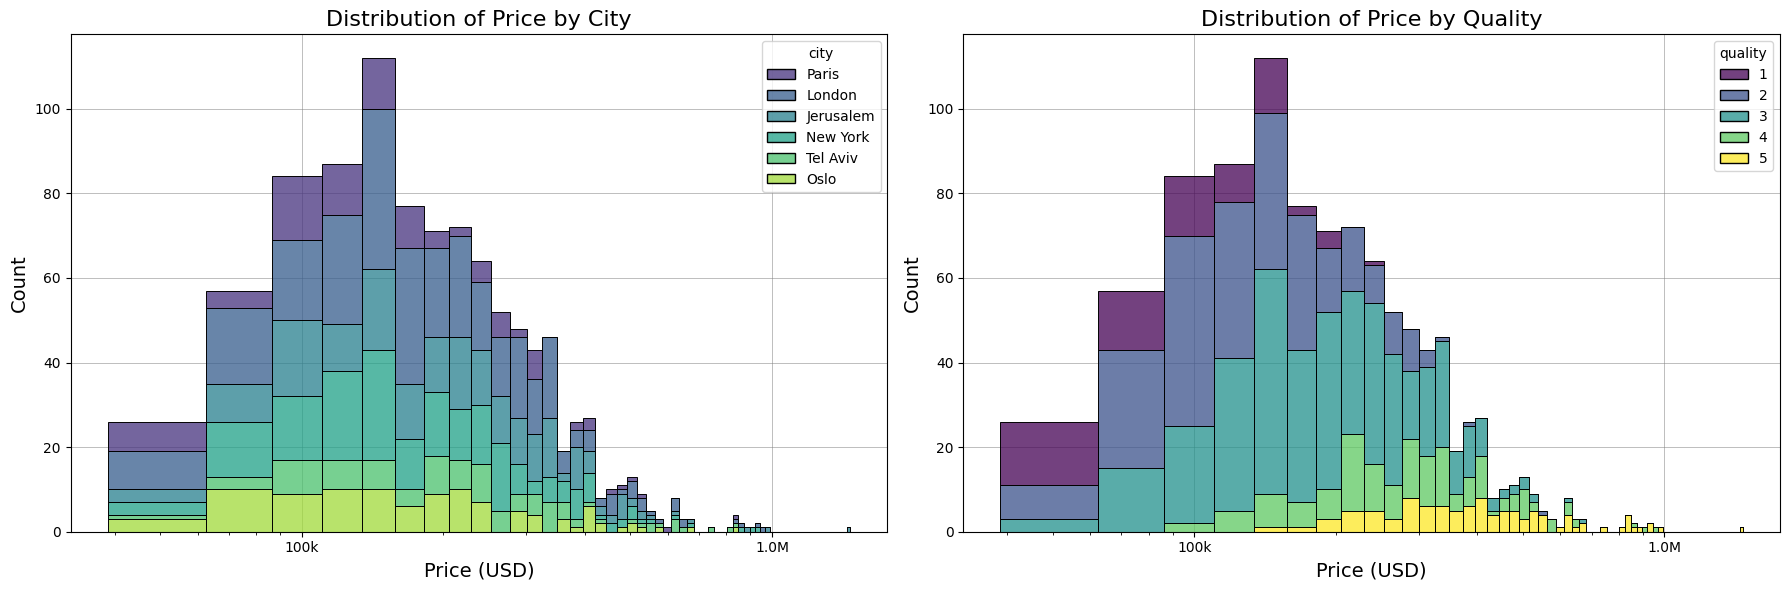

In [ ]:
from matplotlib.ticker import FuncFormatter

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# First plot - by city
sns.histplot(
    data=challenge,
    x="price",
    bins=60,
    hue="city",
    palette="viridis",
    multiple="stack",
    kde=False,
    ax=ax1,
)

ax1.set_xlabel("Price (USD)", fontsize=14)
ax1.set_ylabel("Count", fontsize=14)
ax1.set_title("Distribution of Price by City", fontsize=16)
ax1.set_xscale("log")
ax1.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax1.set_axisbelow(True)

# Second plot - by quality
sns.histplot(
    data=challenge,
    x="price",
    bins=60,
    hue="quality",
    palette="viridis",
    multiple="stack",
    kde=False,
    ax=ax2,
)

ax2.set_xlabel("Price (USD)", fontsize=14)
ax2.set_ylabel("Count", fontsize=14)
ax2.set_title("Distribution of Price by Quality", fontsize=16)
ax2.set_xscale("log")
ax2.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax2.set_axisbelow(True)


# Shared formatting function
def human_format(x, pos):
    if x >= 1e6:
        return f"{x/1e6:.1f}M"
    if x >= 1e3:
        return f"{x/1e3:.0f}k"
    return f"{x:.0f}"


# Apply formatting to both subplots
ax1.xaxis.set_major_formatter(FuncFormatter(human_format))
ax2.xaxis.set_major_formatter(FuncFormatter(human_format))

# Add legends only if labels exist
handles1, labels1 = ax1.get_legend_handles_labels()
if labels1:
    ax1.legend(
        handles1,
        labels1,
        title="City",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=13,
    )

handles2, labels2 = ax2.get_legend_handles_labels()
if labels2:
    ax2.legend(
        handles2,
        labels2,
        title="Quality",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=13,
    )

plt.tight_layout()
plt.show()

### Sanity check for correlation between price and quality

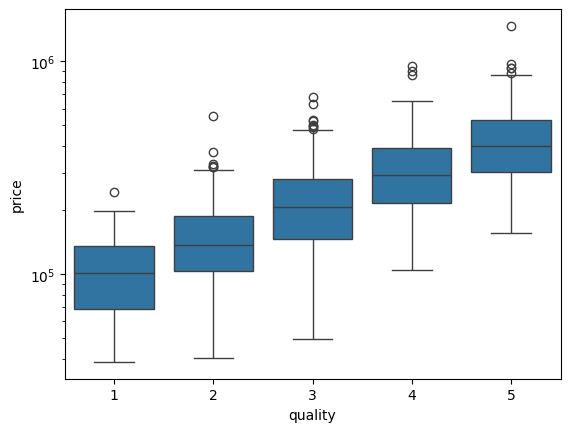

In [ ]:
sns.boxplot(data=challenge, x="quality", y="price")
plt.yscale("log")